## Load Library

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import signal, stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import time
import pickle
from sklearn.metrics import r2_score
import statsmodels.api as sm
from neuralop.models import FNO
from PatchTST_Code.PatchTST_Regressor import PatchTSTMaterialRegressor

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="networkx.utils.backends")

## Training parameters

In [2]:
num_epochs = 1000
save_every = 100
learning_rate = 0.000001
batch_size = 16
model_num = 6
num_samples = 6560   # Keep simulated data, upsample experimental data
duration = 15.47
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load and processing data

### Simulated data

In [3]:
# Load cvs file and convert it to numpy
data_dir = 'C:\Research\Radar Signal Domain Adaptation\Single_Layer'
fname = os.path.join(data_dir, '1_layer_SimData_1547.csv')
SimData = pd.read_csv(fname).to_numpy()

In [4]:
# Seperate data and label
Sim_Data = SimData[:,3:]    
Sim_Label = SimData[:,0:3]

SimTime = np.arange(15.47/6560,15.47+15.47/6560,15.47/6560)[:-1] # Total time is 15.47 ns

SimTrain_Data = Sim_Data
SimTrain_Label = Sim_Label

In [5]:
# Check data size
print(SimTrain_Data.shape)
print(SimTrain_Label.shape)

(16500, 6560)
(16500, 3)


### Experimental data

In [6]:
fname = os.path.join(data_dir, '1_layer_TEST_ExpData.xlsx')
ExpTest = pd.read_excel(fname)

# Time
ExpTest_Time_1 = np.tile(ExpTest.iloc[2, 4:514].to_numpy(), (25,1))
ExpTest_Time_2 = np.tile(ExpTest.iloc[33, 4:514].to_numpy(), (25,1))
ExpTest_Time_3 = np.tile(ExpTest.iloc[65, 4:514].to_numpy(), (25,1))
ExpTest_Time_4 = np.tile(ExpTest.iloc[97, 4:514].to_numpy(), (25,1))
ExpTest_Time_5 = np.tile(ExpTest.iloc[129, 4:514].to_numpy(), (25,1))
ExpTest_Time_6 = np.tile(ExpTest.iloc[162, 4:514].to_numpy(), (25,1))
ExpTest_Time = np.concatenate((ExpTest_Time_1, ExpTest_Time_2, ExpTest_Time_3, ExpTest_Time_4,
                               ExpTest_Time_5, ExpTest_Time_6), axis=0)

# Label
ExpTest_Label_1 = ExpTest.iloc[3:28, 0:3].to_numpy()
ExpTest_Label_2 = ExpTest.iloc[34:59, 0:3].to_numpy()
ExpTest_Label_3 = ExpTest.iloc[66:91, 0:3].to_numpy()
ExpTest_Label_4 = ExpTest.iloc[98:123, 0:3].to_numpy()
ExpTest_Label_5 = ExpTest.iloc[130:155, 0:3].to_numpy()
ExpTest_Label_6 = ExpTest.iloc[163:188, 0:3].to_numpy()
ExpTest_Label = np.concatenate((ExpTest_Label_1, ExpTest_Label_2, ExpTest_Label_3, ExpTest_Label_4, 
                                ExpTest_Label_5, ExpTest_Label_6), axis=0)

# Data
ExpTest_Data_1 = ExpTest.iloc[3:28, 4:514].to_numpy()
ExpTest_Data_2 = ExpTest.iloc[34:59, 4:514].to_numpy()
ExpTest_Data_3 = ExpTest.iloc[66:91, 4:514].to_numpy()
ExpTest_Data_4 = ExpTest.iloc[98:123, 4:514].to_numpy()
ExpTest_Data_5 = ExpTest.iloc[130:155, 4:514].to_numpy()
ExpTest_Data_6 = ExpTest.iloc[163:188, 4:514].to_numpy()
ExpTest_Data = np.concatenate((ExpTest_Data_1, ExpTest_Data_2, ExpTest_Data_3, ExpTest_Data_4, 
                               ExpTest_Data_5, ExpTest_Data_6), axis=0)

In [7]:
# Check data size
print(ExpTest_Label.shape)
print(ExpTest_Data.shape)

(150, 3)
(150, 510)


### Processing dataset

In [8]:
# Process the signal to ensure a consistent duration and number of samples
def signal_processing(input_signal, time, duration, num_samples):
    idx = (np.abs(time - duration)).argmin()                       # Find the index corresponding to the specified duration
    truncate_siganl = input_signal[0:idx]                          # Truncate the signal to the specified duration
    output_signal = signal.resample(truncate_siganl, num_samples)  # Generate the signal with the specified number of samples
    return output_signal

# Normalize the signal using min-max normalization
def norm(input_signal):
    input_signal = input_signal/np.max(input_signal)
    return input_signal

# Shift signal to ensure the same start time in both simulated and experimental signals
def signal_shifting(sim_signal, exp_signal, sim_time, exp_time):
    sim_max_index = np.argmax(sim_signal)       # Find the index of the maximum value of simulated signal
    sim_max_time = sim_time[sim_max_index]      # Find the time of the maximum value of simulated signal
    exp_max_index = np.argmax(exp_signal)       # Find the index of the maximum value of experimental signal
    exp_max_time = exp_time[exp_max_index]      # Find the time of the maximum value of experimental signal
    time_diff = exp_max_time-sim_max_time       # Calcualte the time difference between simulated and experimental signals
    shift_index = np.absolute(exp_time-time_diff).argmin()    # Find the index of where the experimental signal should start
    exp_signal_shift = exp_signal[shift_index:]               # Remove the samples at the begining of the experimental signal
    exp_time_shift = exp_time[:len(exp_time)-shift_index]     # Update the time vector of the experimental signal
    return exp_signal_shift, exp_time_shift

In [9]:
unified_time = np.arange(duration/num_samples,duration+duration/num_samples,duration/num_samples)[:-1]
ExpTest_Data_Pro = np.zeros((ExpTest_Data.shape[0],num_samples))
SimTrain_Data_Pro = SimTrain_Data    # Simulated data already normalized

# Keep simulated data, upsample experimental data
for i in range(ExpTest_Data.shape[0]):
    exp_signal_shift, exp_time_shift = signal_shifting(SimTrain_Data[0], ExpTest_Data[i], SimTime, ExpTest_Time[i])
    ExpTest_Data_Pro[i] = norm(signal_processing(exp_signal_shift, exp_time_shift, duration, num_samples))

In [10]:
# Normalize the training labels
SimTrain_Label_Pro = np.zeros((SimTrain_Label.shape))

for i in range(SimTrain_Label.shape[1]):
    SimTrain_Label_Pro[:,i] = (SimTrain_Label[:,i] - np.min(SimTrain_Label[:,i])) /\
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i]))

In [11]:
# Check data size
print(ExpTest_Data_Pro.shape)

(150, 6560)


### Build data loader

In [12]:
# Train loader
SimTrain_Data_Pro_Tensor = torch.tensor(SimTrain_Data_Pro, dtype=torch.float32)
SimTrain_Label_Pro_Tensor = torch.tensor(SimTrain_Label_Pro, dtype=torch.float32)
Train_Dataset = TensorDataset(SimTrain_Data_Pro_Tensor,SimTrain_Label_Pro_Tensor)
Train_Loader = DataLoader(Train_Dataset, batch_size, shuffle=True)

## Build PatchTST model

In [13]:
PatchTST = PatchTSTMaterialRegressor(
    seq_len=6560,
    out_dim=3,
    c_in=1,
    patch_len=256,
    stride=64,
    d_model=128,
    n_heads=4,
    n_layers=3,
    d_ff=256,
    dropout=0.1,
    revin=True,
    decomposition=False,
    pool_vars="mean",
).to(device)

summary(
    PatchTST,
    input_size=(1, 6560),   # (batch_size, L)
    device=str(device)
)


Layer (type:depth-idx)                                                 Output Shape              Param #
PatchTSTMaterialRegressor                                              [1, 3]                    --
├─PatchTST_backbone: 1-1                                               [1, 1, 128, 99]           12,673
│    └─RevIN: 2-1                                                      [1, 6560, 1]              2
│    └─TSTiEncoder: 2-2                                                [1, 1, 128, 99]           12,672
│    │    └─Linear: 3-1                                                [1, 1, 99, 128]           32,896
│    │    └─Dropout: 3-2                                               [1, 99, 128]              --
│    │    └─TSTEncoder: 3-3                                            [1, 99, 128]              397,443
├─Sequential: 1-2                                                      [1, 3]                    --
│    └─LayerNorm: 2-3                                                  [1, 1267

## Utility functions

In [14]:
def _save_checkpoint(epoch):
    ckp = PatchTST.state_dict()
    path = f'./Saved_Model/PatchTST_Model_{model_num}/checkpoint_{epoch+1}.pt'
    torch.save(ckp, path)
    with open(f'./Saved_Model/PatchTST_Model_{model_num}/trainHistoryDict_{epoch+1}', 'wb') as file_pi:
        pickle.dump(loss_hist, file_pi)
    print(f'Epoch {epoch+1} | Training checkpoint saved at {path}')

In [15]:
def _load_checkpoint(epoch):
# Load trained PatchTST
    path = f'./Saved_Model/PatchTST_Model_{model_num}/checkpoint_{epoch}.pt'
    sd = torch.load(path, map_location="cpu", weights_only=False)  # ONLY if you trust the file

    # If this is a checkpoint dict, extract the state dict
    if isinstance(sd, dict) and any(k in sd for k in ["model_state_dict", "state_dict"]):
        sd = sd.get("model_state_dict", sd.get("state_dict"))
    
    # Remove non-parameter bookkeeping if present
    if isinstance(sd, dict):
        sd.pop("_metadata", None)

    PatchTST.load_state_dict(sd, strict=True)

## Compile and train PatchTST model

In [16]:
# Instantiate and train
PatchTST = PatchTSTMaterialRegressor(
    seq_len=6560,
    out_dim=3,
    c_in=1,
    patch_len=256,
    stride=64,
    d_model=128,
    n_heads=4,
    n_layers=3,
    d_ff=256,
    dropout=0.1,
    revin=True,
    decomposition=False,
    pool_vars="mean",
).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(PatchTST.parameters(), lr=learning_rate)

In [17]:
# Training loop
start_time = time.time()
loss_hist = []

for epoch in range(num_epochs):
    PatchTST.train()
    epoch_loss = 0.0

    for batch_x, batch_y in Train_Loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float()

        pred = PatchTST(batch_x)
        loss = criterion(pred, batch_y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(Train_Loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")
    loss_hist.append(avg_loss)

    if save_every is not None and (epoch+1) % save_every == 0:
        _save_checkpoint(epoch)

end_time = time.time()
print(f"Training time: {(end_time - start_time) / 60:.1f} min")

Epoch 1/1000, Loss: 0.064199
Epoch 2/1000, Loss: 0.034426
Epoch 3/1000, Loss: 0.025580
Epoch 4/1000, Loss: 0.020247
Epoch 5/1000, Loss: 0.016369
Epoch 6/1000, Loss: 0.013415
Epoch 7/1000, Loss: 0.011335
Epoch 8/1000, Loss: 0.009810
Epoch 9/1000, Loss: 0.008749
Epoch 10/1000, Loss: 0.007902
Epoch 11/1000, Loss: 0.007172
Epoch 12/1000, Loss: 0.006530
Epoch 13/1000, Loss: 0.006033
Epoch 14/1000, Loss: 0.005629
Epoch 15/1000, Loss: 0.005307
Epoch 16/1000, Loss: 0.004982
Epoch 17/1000, Loss: 0.004699
Epoch 18/1000, Loss: 0.004467
Epoch 19/1000, Loss: 0.004285
Epoch 20/1000, Loss: 0.004061
Epoch 21/1000, Loss: 0.003913
Epoch 22/1000, Loss: 0.003721
Epoch 23/1000, Loss: 0.003639
Epoch 24/1000, Loss: 0.003500
Epoch 25/1000, Loss: 0.003416
Epoch 26/1000, Loss: 0.003210
Epoch 27/1000, Loss: 0.003138
Epoch 28/1000, Loss: 0.003128
Epoch 29/1000, Loss: 0.003033
Epoch 30/1000, Loss: 0.002954
Epoch 31/1000, Loss: 0.002866
Epoch 32/1000, Loss: 0.002779
Epoch 33/1000, Loss: 0.002713
Epoch 34/1000, Loss

## Test loss curve

In [16]:
Test_R_all = np.zeros((int(num_epochs/save_every),1))

for j in range(int(num_epochs/save_every)):
    
    # Load trained PatchTST
    _load_checkpoint((j+1)*100)
    
    # Evaluate using the testing dataset
    PatchTST.eval()
    with torch.no_grad():
        ExpTest_Pred_Pro = PatchTST(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1).to(device))
    ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()

    # De-normalize the predictions
    ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

    for i in range(ExpTest_Pred_Pro.shape[1]):
        ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
            (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])
    
    # Calculate R
    Test_R_all[j] = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]

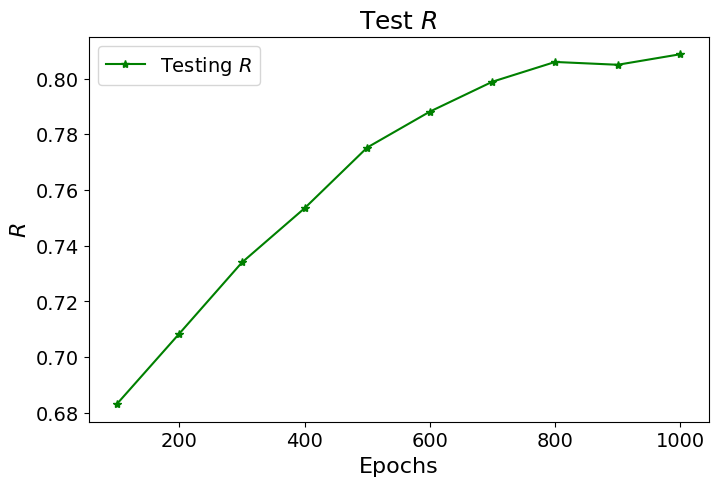

The highest test R is achieved at Epoch: 1000


In [17]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(100,num_epochs+1,100), Test_R_all, 'g-*', label='Testing $R$')
plt.title('Test $R$',fontsize=18)
plt.xlabel('Epochs',fontsize=16)
plt.ylabel('$R$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

epoch = int((np.where(Test_R_all == Test_R_all.max())[0][0] + 1) * 100)
print(f'The highest test R is achieved at Epoch: {epoch}')

## Load trained PatchTST model

In [18]:
select_epochs = 1000

In [19]:
# Load trained PatchTST
_load_checkpoint(select_epochs)

# Load train history
with open(f'./Saved_Model/PatchTST_Model_{model_num}/trainHistoryDict_{select_epochs}', 'rb') as file_pi:
        loss_hist = pickle.load(file_pi)

## Evaluate using experimental tesing dataset

In [20]:
# Evaluate using the experimental testing dataset
PatchTST.eval()
with torch.no_grad():
    ExpTest_Pred_Pro = PatchTST(torch.unsqueeze(torch.tensor(ExpTest_Data_Pro, dtype=torch.float32),1).to(device))
ExpTest_Pred_Pro = ExpTest_Pred_Pro.cpu().numpy()
    
# De-normalize the predictions
ExpTest_Pred = np.zeros((ExpTest_Pred_Pro.shape))

for i in range(ExpTest_Pred_Pro.shape[1]):
    ExpTest_Pred[:,i] = ExpTest_Pred_Pro[:,i] * \
        (np.max(SimTrain_Label[:,i]) - np.min(SimTrain_Label[:,i])) + np.min(SimTrain_Label[:,i])

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred[:,0] - ExpTest_Label[:,0]) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label[:,0], ExpTest_Pred[:,0])
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label[:,0].astype(float), ExpTest_Pred[:,0].astype(float))[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred[:,0]) - np.mean(ExpTest_Label[:,0])
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 MSE on experimental tesing dataset: 49.1569913275
p1 R2 on experimental tesing dataset: -3.6869499372
p1 R on experimental tesing dataset: 0.7865375988
p1 Bias on experimental tesing dataset: -6.7078450044


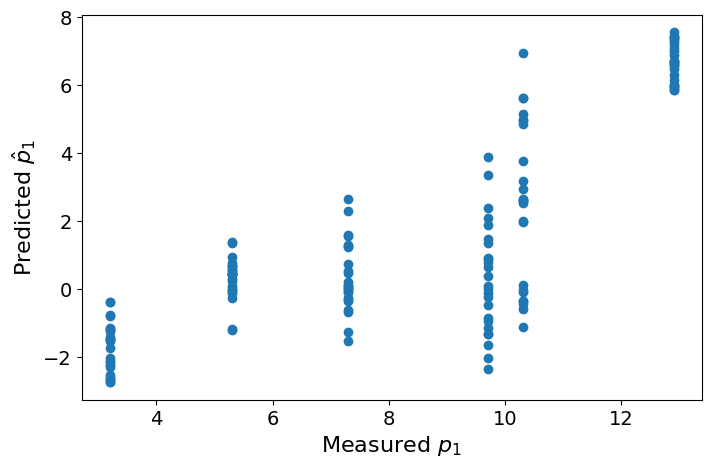

In [21]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,0],ExpTest_Pred[:,0])
plt.xlabel('Measured $p_1$',fontsize=16)
plt.ylabel('Predicted $\hat{p}_1$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [22]:
# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred[:,1] - ExpTest_Label[:,1]) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label[:,1], ExpTest_Pred[:,1])
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label[:,1].astype(float), ExpTest_Pred[:,1].astype(float))[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred[:,1]) - np.mean(ExpTest_Label[:,1])
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 MSE on experimental tesing dataset: 0.0002660738
c1 R2 on experimental tesing dataset: 0.2257899425
c1 R on experimental tesing dataset: 0.8087768426
c1 Bias on experimental tesing dataset: -0.0081997276


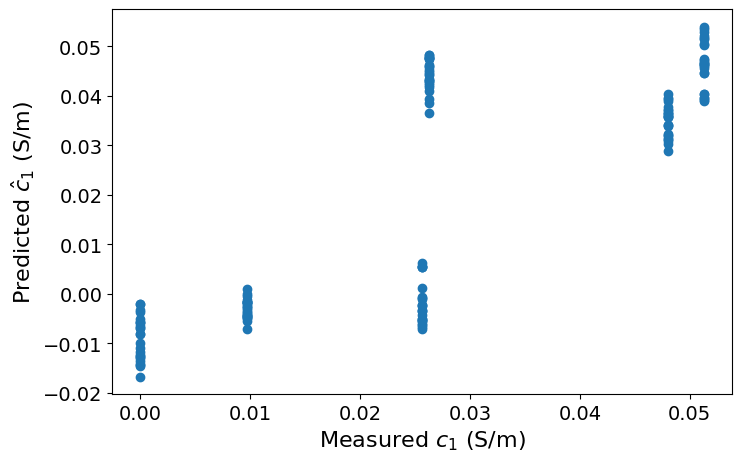

In [23]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,1],ExpTest_Pred[:,1])
plt.xlabel('Measured $c_1$ (S/m)',fontsize=16)
plt.ylabel('Predicted $\hat{c}_1$ (S/m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [24]:
# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred[:,2] - ExpTest_Label[:,2]) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label[:,2], ExpTest_Pred[:,2])
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label[:,2].astype(float), ExpTest_Pred[:,2].astype(float))[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred[:,2]) - np.mean(ExpTest_Label[:,2])
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

d1 MSE on experimental tesing dataset: 0.0039041566
d1 R2 on experimental tesing dataset: -1266971262100680556791421992960.0000000000
d1 R on experimental tesing dataset: -0.0000000000
d1 Bias on experimental tesing dataset: 0.0171783132


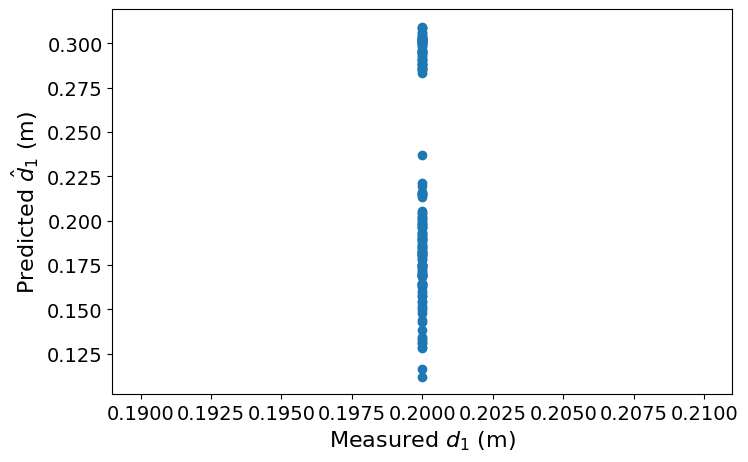

In [25]:
fig = plt.figure(figsize=(8, 5))
plt.scatter(ExpTest_Label[:,2],ExpTest_Pred[:,2])
plt.xlabel('Measured $d_1$ (m)',fontsize=16)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [26]:
specimen_1_pred_mean_p1 = np.mean(ExpTest_Pred[0:25,0])
specimen_2_pred_mean_p1 = np.mean(ExpTest_Pred[25:50,0])
specimen_3_pred_mean_p1 = np.mean(ExpTest_Pred[50:75,0])
specimen_4_pred_mean_p1 = np.mean(ExpTest_Pred[75:100,0])
specimen_5_pred_mean_p1 = np.mean(ExpTest_Pred[100:125,0])
specimen_6_pred_mean_p1 = np.mean(ExpTest_Pred[125:150,0])
ExpTest_Pred_Pro_p1 = np.array([specimen_1_pred_mean_p1,specimen_2_pred_mean_p1,specimen_3_pred_mean_p1,
                                    specimen_4_pred_mean_p1,specimen_5_pred_mean_p1,specimen_6_pred_mean_p1])
ExpTest_Label_Pro_p1 = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],
                                    ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

In [27]:
# R^2
ExpTest_R2_p1 = r2_score(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)
print('p1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_p1))

# Mean square error
ExpTest_MSE_p1 = np.mean((ExpTest_Pred_Pro_p1 - ExpTest_Label_Pro_p1) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_p1))

# R
ExpTest_R_p1 = np.corrcoef(ExpTest_Label_Pro_p1,ExpTest_Pred_Pro_p1)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (ExpTest_R_p1))

# Bias
ExpTest_Bias_p1 = np.mean(ExpTest_Pred_Pro_p1) - np.mean(ExpTest_Label_Pro_p1)
print('p1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_p1))

p1 R2 on experimental tesing dataset: -3.5272197215
p1 MSE on experimental tesing dataset: 47.4817319517
p1 R on experimental tesing dataset: 0.8752958682
p1 Bias on experimental tesing dataset: -6.7078450044


p1 R on experimental tesing dataset: 0.8752958682
p1 Bias on experimental tesing dataset: -6.7078450044
p1 MSE on experimental tesing dataset: 47.4817319517
p1 RMSE on experimental tesing dataset: 6.8906989451
p1 ubMSE on experimental tesing dataset: 1.5768789899


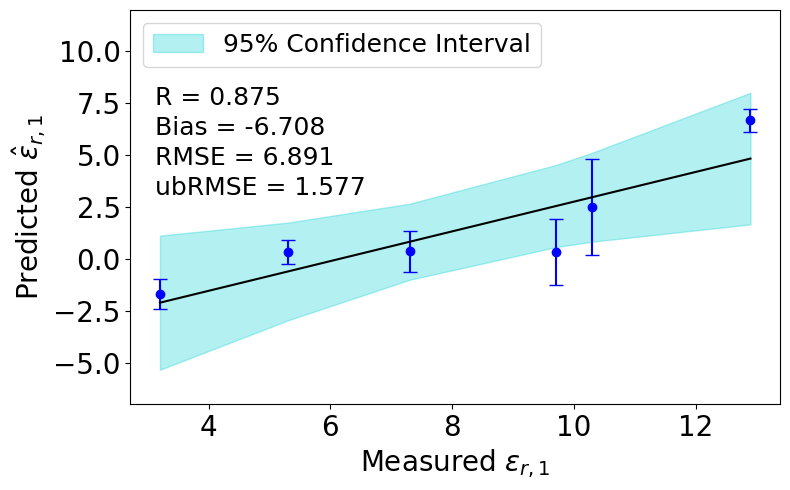

In [28]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,0])
mean_2 = np.mean(ExpTest_Pred[25:50,0])
mean_3 = np.mean(ExpTest_Pred[50:75,0])
mean_4 = np.mean(ExpTest_Pred[75:100,0])
mean_5 = np.mean(ExpTest_Pred[100:125,0])
mean_6 = np.mean(ExpTest_Pred[125:150,0])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,0])
std_2 = np.std(ExpTest_Pred[25:50,0])
std_3 = np.std(ExpTest_Pred[50:75,0])
std_4 = np.std(ExpTest_Pred[75:100,0])
std_5 = np.std(ExpTest_Pred[100:125,0])
std_6 = np.std(ExpTest_Pred[125:150,0])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,0],ExpTest_Label[25,0],ExpTest_Label[50,0],ExpTest_Label[75,0],ExpTest_Label[100,0],ExpTest_Label[125,0]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('p1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('p1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('p1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('p1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('p1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='darkturquoise', alpha=0.3, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='black', alpha=0.2, label='95% Prediction Interval')

plt.xlabel(r'Measured $\varepsilon_{r,1}$',fontsize=20)
plt.ylabel(r'Predicted $\hat{\varepsilon}_{r,1}$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.2, 0.78, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.2, 0.72, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.2, 0.66, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.2, 0.60, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-7,12])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Permittivity_PatchTST_AllSamples', dpi=600)

In [29]:
specimen_1_pred_mean_c1 = np.mean(ExpTest_Pred[0:25,1])
specimen_2_pred_mean_c1 = np.mean(ExpTest_Pred[25:50,1])
specimen_3_pred_mean_c1 = np.mean(ExpTest_Pred[50:75,1])
specimen_4_pred_mean_c1 = np.mean(ExpTest_Pred[75:100,1])
specimen_5_pred_mean_c1 = np.mean(ExpTest_Pred[100:125,1])
specimen_6_pred_mean_c1 = np.mean(ExpTest_Pred[125:150,1])
ExpTest_Pred_Pro_c1 = np.array([specimen_1_pred_mean_c1,specimen_2_pred_mean_c1,specimen_3_pred_mean_c1,
                                    specimen_4_pred_mean_c1,specimen_5_pred_mean_c1,specimen_6_pred_mean_c1])
ExpTest_Label_Pro_c1 = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],
                                    ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

In [30]:
# R^2
ExpTest_R2_c1 = r2_score(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)
print('c1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_c1))

# Mean square error
ExpTest_MSE_c1 = np.mean((ExpTest_Pred_Pro_c1 - ExpTest_Label_Pro_c1) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_c1))

# R
ExpTest_R_c1 = np.corrcoef(ExpTest_Label_Pro_c1,ExpTest_Pred_Pro_c1)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (ExpTest_R_c1))

# Bias
ExpTest_Bias_c1 = np.mean(ExpTest_Pred_Pro_c1) - np.mean(ExpTest_Label_Pro_c1)
print('c1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_c1))

c1 R2 on experimental tesing dataset: 0.2653320914
c1 MSE on experimental tesing dataset: 0.0002524843
c1 R on experimental tesing dataset: 0.8185427306
c1 Bias on experimental tesing dataset: -0.0081997276


c1 R on experimental tesing dataset: 0.8185427306
c1 Bias on experimental tesing dataset: -0.0081997276
c1 MSE on experimental tesing dataset: 0.0002524843
c1 RMSE on experimental tesing dataset: 0.0158897558
c1 ubMSE on experimental tesing dataset: 0.0136106138


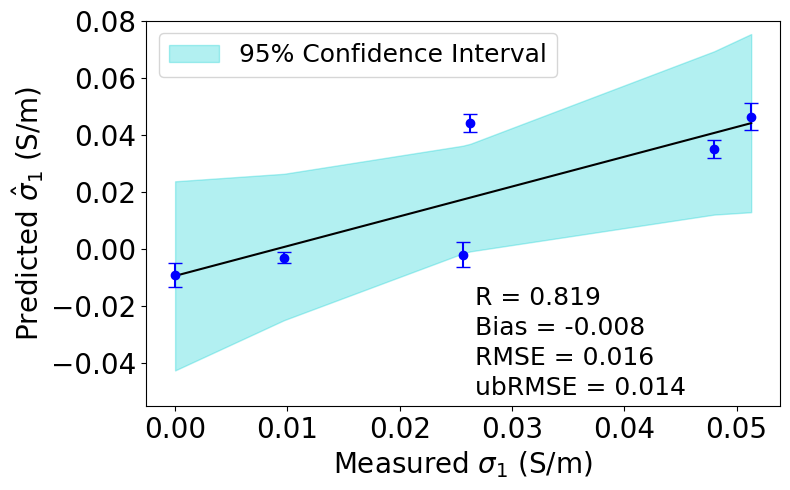

In [31]:
# Mean of predictions
mean_1 = np.mean(ExpTest_Pred[0:25,1])
mean_2 = np.mean(ExpTest_Pred[25:50,1])
mean_3 = np.mean(ExpTest_Pred[50:75,1])
mean_4 = np.mean(ExpTest_Pred[75:100,1])
mean_5 = np.mean(ExpTest_Pred[100:125,1])
mean_6 = np.mean(ExpTest_Pred[125:150,1])

# Standard deviation of predictions
std_1 = np.std(ExpTest_Pred[0:25,1])
std_2 = np.std(ExpTest_Pred[25:50,1])
std_3 = np.std(ExpTest_Pred[50:75,1])
std_4 = np.std(ExpTest_Pred[75:100,1])
std_5 = np.std(ExpTest_Pred[100:125,1])
std_6 = np.std(ExpTest_Pred[125:150,1])

pred_mean = np.array([mean_1,mean_2,mean_3,mean_4,mean_5,mean_6])
std_mean = np.array([std_1,std_2,std_3,std_4,std_5,std_6])
label = np.array([ExpTest_Label[0,1],ExpTest_Label[25,1],ExpTest_Label[50,1],ExpTest_Label[75,1],ExpTest_Label[100,1],ExpTest_Label[125,1]])

# R
R = np.corrcoef(label,pred_mean)[0,1]
print('c1 R on experimental tesing dataset: %.10f' % (R))

# Bias
Bias = np.mean(pred_mean) - np.mean(label)
print('c1 Bias on experimental tesing dataset: %.10f' % (Bias))

# MSE
MSE = np.mean((pred_mean - label) ** 2)
print('c1 MSE on experimental tesing dataset: %.10f' % (MSE))

# RMSE
RMSE = np.sqrt(MSE)
print('c1 RMSE on experimental tesing dataset: %.10f' % (RMSE))

# ubRMSE
ubRMSE = np.sqrt((RMSE ** 2 - Bias ** 2))
print('c1 ubMSE on experimental tesing dataset: %.10f' % (ubRMSE))

# Error bar plots
fig = plt.figure(figsize=(8, 5))
plt.errorbar(label, pred_mean, yerr=std_mean, fmt='o', color='b', capsize=5)

# Fit the OLS model
label_ = sm.add_constant(label)
OLSmodel = sm.OLS(pred_mean, label_)
results = OLSmodel.fit()
predictions = results.get_prediction(label_)
summary_frame = predictions.summary_frame(alpha=0.05) # 95% confidence level

# Confidence interval for the mean response
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

# Prediction interval for individual observations
pi_lower = summary_frame['obs_ci_lower']
pi_upper = summary_frame['obs_ci_upper']

plt.plot(label, results.predict(label_), color='black')
# plt.scatter(ExpTest_Label_Pro_p1, ExpTest_Pred_Pro_p1)

# Plotting the Confidence Interval (CI)
plt.fill_between(label, ci_lower, ci_upper, color='darkturquoise', alpha=0.3, label='95% Confidence Interval')

# Plotting the Prediction Interval (PI)
# plt.fill_between(label, pi_lower, pi_upper, color='black', alpha=0.2, label='95% Prediction Interval')

plt.xlabel(r'Measured $\sigma_1$ (S/m)',fontsize=20)
plt.ylabel(r'Predicted $\hat{\sigma}_1$ (S/m)', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.figtext(0.6, 0.38, f'R = %.3f' % R, fontsize=18)
plt.figtext(0.6, 0.32, f'Bias = %.3f' % Bias, fontsize=18)
plt.figtext(0.6, 0.26, f'RMSE = %.3f' % RMSE, fontsize=18)
plt.figtext(0.6, 0.20, f'ubRMSE = %.3f' % ubRMSE, fontsize=18)
# plt.figtext(0.15, 0.70, f'Bias = %.3f' % results.params[0], fontsize=14)
plt.legend(fontsize=18, loc='upper left')
plt.ylim([-0.055,0.08])
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Conductivity_PatchTST_AllSamples', dpi=600)

In [32]:
specimen_1_pred_mean_d1 = np.mean(ExpTest_Pred[0:25,2])
specimen_2_pred_mean_d1 = np.mean(ExpTest_Pred[25:50,2])
specimen_3_pred_mean_d1 = np.mean(ExpTest_Pred[50:75,2])
specimen_4_pred_mean_d1 = np.mean(ExpTest_Pred[75:100,2])
specimen_5_pred_mean_d1 = np.mean(ExpTest_Pred[100:125,2])
specimen_6_pred_mean_d1 = np.mean(ExpTest_Pred[125:150,2])
ExpTest_Pred_Pro_d1 = np.array([specimen_1_pred_mean_d1,specimen_2_pred_mean_d1,specimen_3_pred_mean_d1,
                                    specimen_4_pred_mean_d1,specimen_5_pred_mean_d1,specimen_6_pred_mean_d1])
ExpTest_Label_Pro_d1 = np.array([ExpTest_Label[0,2],ExpTest_Label[25,2],ExpTest_Label[50,2],
                                    ExpTest_Label[75,2],ExpTest_Label[100,2],ExpTest_Label[125,2]])

In [33]:
# R^2
ExpTest_R2_d1 = r2_score(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)
print('d1 R2 on experimental tesing dataset: %.10f' % (ExpTest_R2_d1))

# Mean square error
ExpTest_MSE_d1 = np.mean((ExpTest_Pred_Pro_d1 - ExpTest_Label_Pro_d1) ** 2)
print('d1 MSE on experimental tesing dataset: %.10f' % (ExpTest_MSE_d1))

# R
ExpTest_R_d1 = np.corrcoef(ExpTest_Label_Pro_d1,ExpTest_Pred_Pro_d1)[0,1]
print('d1 R on experimental tesing dataset: %.10f' % (ExpTest_R_d1))

# Bias
ExpTest_Bias_d1 = np.mean(ExpTest_Pred_Pro_d1) - np.mean(ExpTest_Label_Pro_d1)
print('d1 Bias on experimental tesing dataset: %.10f' % (ExpTest_Bias_d1))

# RMSE
ExpTest_RMSE_d1 = np.sqrt(ExpTest_MSE_d1)
print('d1 RMSE on experimental tesing dataset: %.10f' % (ExpTest_RMSE_d1))

# ubRMSE
ExpTest_ubRMSE_d1 = np.sqrt((ExpTest_RMSE_d1 ** 2 - ExpTest_Bias_d1 ** 2))
print('d1 ubRMSE on experimental tesing dataset: %.10f' % (ExpTest_ubRMSE_d1))

d1 R2 on experimental tesing dataset: -4823701087743555785732407689216.0000000000
d1 MSE on experimental tesing dataset: 0.0037160441
d1 R on experimental tesing dataset: -0.0000000000
d1 Bias on experimental tesing dataset: 0.0171783132
d1 RMSE on experimental tesing dataset: 0.0609593647
d1 ubRMSE on experimental tesing dataset: 0.0584888853


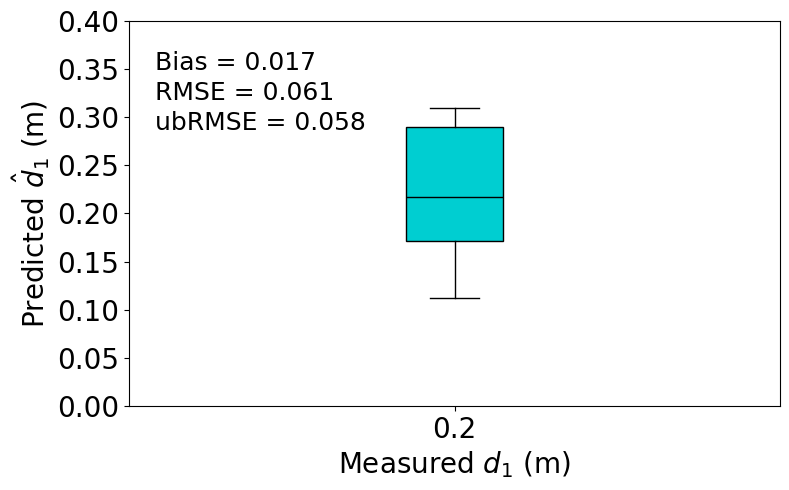

In [34]:
# Box plot
fig = plt.figure(figsize=(8, 5))
box = plt.boxplot(ExpTest_Pred[:,2],patch_artist=True,meanline=True,showmeans=True)
colors = ['darkturquoise']
# fill with colors
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    # patch.set_alpha(0.6)
for mean in box['means']:
    mean.set_color('black')
    mean.set_linestyle('solid')
for median in box['medians']:
    median.set_linewidth(0)

plt.xlabel('Measured $d_1$ (m)',fontsize=20)
plt.ylabel('Predicted $\hat{d}_1$ (m)',fontsize=20)
labels = ['0.2']
plt.xticks([1], labels, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.ylim([0,0.4])
plt.figtext(0.2, 0.85, f'Bias = %.3f' % ExpTest_Bias_d1, fontsize=18)
plt.figtext(0.2, 0.79, f'RMSE = %.3f' % ExpTest_RMSE_d1, fontsize=18)
plt.figtext(0.2, 0.73, f'ubRMSE = %.3f' % ExpTest_ubRMSE_d1, fontsize=18)
plt.tight_layout()
plt.show()
fig.savefig('./OneLayer_ThreeParam_Depth_PatchTST_AllSamples', dpi=600)

In [35]:
np.std(ExpTest_Pred[:,2])

0.06007547071940017